# arc.csv — Variance and Distribution by Experiment
This notebook loads `arc.csv` and shows per-experiment variance and distributions for each feature.

In [291]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk', palette='deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 120,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
})


In [292]:
group = "9"
if group == "0":
    split_config_path = 'config/data-split-config/train_test_split_each_setup_80.json'
else:
    split_config_path = f'config/data-split-config/train_test_split_based_on_column_gp{group}.json'
from pathlib import Path
dir_path = Path("results") / "split_groups_distribution" / f"{group}"

dir_path.mkdir(parents=True, exist_ok=True)


In [293]:
df = pd.read_csv('arc.csv')
df.head()

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.0,22.145797,21.453291,0.031511,-0.523025
1,2,1.0,22.147194,21.507501,0.029108,-0.468815
2,2,2.0,22.146727,21.587299,0.025456,-0.389017
3,2,3.0,22.145979,21.664488,0.021910,-0.311828
4,2,4.0,22.147433,21.720590,0.019423,-0.255727


In [294]:
# Identify numeric feature columns (excluding Experiment_ID and angle column)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
angle_col = 'Angle[degree]ORDistance[mm]'
feature_cols = [c for c in numeric_cols if c not in ['Experiment_ID', angle_col]]
feature_cols

['Secondary-axis [mm]',
 'Main-axis [mm]',
 'Out-of-roundness [-]',
 'Collapse [mm]']

In [295]:
import json
unique_experiment_ids_file_path = Path("data")/"ml"/"unique_experiment_ids.json"
with open(unique_experiment_ids_file_path, "r") as f:
    unique_experiments = json.load(f)

In [296]:
'''
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

xcol = "Angle[degree]ORDistance[mm]"
GREY_AREA_COLOR = "grey"
GREY_AREA_ALPHA = 0.15

for experiment_group in unique_experiments:
    df_selected = df[df["Experiment_ID"].isin(experiment_group)].copy()

    fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axs = axs.ravel()  # flatten 2x2 into 1D list

    # Common x-grid for this group
    x_grid = np.sort(df_selected[xcol].dropna().unique())

    # Helper: interpolate y-values onto x_grid
    def interp_to_grid(dfg, feature):
        dfg = dfg[[xcol, feature]].dropna().sort_values(xcol)
        x = dfg[xcol].to_numpy()
        y = dfg[feature].to_numpy()

        if len(x) < 2:
            return np.full_like(x_grid, np.nan, dtype=float)

        y_interp = np.interp(x_grid, x, y)
        # mask values outside original range to avoid fake flat extrapolation
        y_interp[x_grid < x.min()] = np.nan
        y_interp[x_grid > x.max()] = np.nan
        return y_interp

    # Cache each experiment dataframe
    exp_groups = {exp_id: dfg for exp_id, dfg in df_selected.groupby("Experiment_ID")}

    for i, feature in enumerate(feature_cols):
        ax = axs[i]

        # ---- Baseline = mean curve across experiments (on the same x_grid) ----
        y_stack = []
        for exp_id, dfg in exp_groups.items():
            y_stack.append(interp_to_grid(dfg, feature))

        y_stack = np.vstack(y_stack)                 # (n_exps, len(x_grid))
        y_base = np.nanmean(y_stack, axis=0)         # baseline mean curve

        # Plot baseline (optional)
        ax.plot(x_grid, y_base, linewidth=2, label="Baseline (mean)")

        # ---- Plot each exp + grey shaded area between exp and baseline ----
        for exp_id, dfg in exp_groups.items():
            y_exp = interp_to_grid(dfg, feature)

            mask = np.isfinite(y_exp) & np.isfinite(y_base)
            ax.plot(x_grid, y_exp, label=f"Exp {exp_id}")

            ax.fill_between(
                x_grid[mask],
                y_exp[mask],
                y_base[mask],
                color=GREY_AREA_COLOR,
                alpha=GREY_AREA_ALPHA,
                linewidth=0
            )

        ax.set_title(feature)
        ax.set_xlabel("Angle")
        ax.set_ylabel(feature)
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()

    dir_path_variations = Path("results") / "split_groups_distribution" / "variations"
    dir_path_variations.mkdir(parents=True, exist_ok=True)

    file_path = dir_path_variations / f"variation_{experiment_group}.pdf"
    plt.savefig(file_path, dpi=150, bbox_inches="tight")
'''

'\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom pathlib import Path\n\nxcol = "Angle[degree]ORDistance[mm]"\nGREY_AREA_COLOR = "grey"\nGREY_AREA_ALPHA = 0.15\n\nfor experiment_group in unique_experiments:\n    df_selected = df[df["Experiment_ID"].isin(experiment_group)].copy()\n\n    fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)\n    axs = axs.ravel()  # flatten 2x2 into 1D list\n\n    # Common x-grid for this group\n    x_grid = np.sort(df_selected[xcol].dropna().unique())\n\n    # Helper: interpolate y-values onto x_grid\n    def interp_to_grid(dfg, feature):\n        dfg = dfg[[xcol, feature]].dropna().sort_values(xcol)\n        x = dfg[xcol].to_numpy()\n        y = dfg[feature].to_numpy()\n\n        if len(x) < 2:\n            return np.full_like(x_grid, np.nan, dtype=float)\n\n        y_interp = np.interp(x_grid, x, y)\n        # mask values outside original range to avoid fake flat extrapolation\n        y_interp[x_grid < x.min()] = np.nan\n        y_in

In [297]:
import ipywidgets as widgets
from IPython.display import display

# Dropdowns
exp_ids = sorted(df["Experiment_ID"].unique())

exp_dropdown = widgets.Dropdown(
    options=exp_ids,
    value=exp_ids[0],
    description="Experiment:",
)

x_dropdown = widgets.Dropdown(
    options=feature_cols,
    value=feature_cols[0],
    description="X feature:",
)

y_dropdown = widgets.Dropdown(
    options=feature_cols,
    value=feature_cols[1] if len(feature_cols) > 1 else feature_cols[0],
    description="Y feature:",
)

def plot_scatter(experiment_id, x_feature, y_feature):
    mask = df["Experiment_ID"] == experiment_id
    
    plt.figure(figsize=(10, 4))
    plt.scatter(df.loc[mask, x_feature], df.loc[mask, y_feature], s=2, alpha=0.6)
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"Experiment {experiment_id}: {x_feature} vs {y_feature}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

ui = widgets.VBox([exp_dropdown, x_dropdown, y_dropdown])

out = widgets.interactive_output(
    plot_scatter,
    {
        "experiment_id": exp_dropdown,
        "x_feature": x_dropdown,
        "y_feature": y_dropdown,
    }
)

display(ui, out)


Output()

## Split helpers (set JSON path once and reuse)

In [298]:
import json

# Set your split config path here


def load_split_ids(split_config_path):
    with open(split_config_path, 'r') as f:
        split_cfg = json.load(f)
    train_ids = sorted({eid for group in split_cfg['train_groups'] for eid in group})
    test_ids = sorted({eid for group in split_cfg['test_groups'] for eid in group})
    return train_ids, test_ids

def plot_train_test_distributions(split_config_path, df, feature_cols, experiment_col='Experiment_ID'):
    train_ids, test_ids = load_split_ids(split_config_path)
    df_train = df[df[experiment_col].isin(train_ids)].copy()
    df_test = df[df[experiment_col].isin(test_ids)].copy()

    def plot_distributions(title, data, part):
        n = len(feature_cols)
        cols = 2
        rows = int(np.ceil(n / cols))
        plt.figure(figsize=(12, 4 * rows))
        for i, col in enumerate(feature_cols, 1):
            ax = plt.subplot(rows, cols, i)
            sns.histplot(data[col], kde=True, ax=ax, bins=30, color=sns.color_palette()[0], alpha=0.7)
            ax.set_title(f'{title}: {col}')
            ax.grid(True, alpha=0.2)
        sns.despine()
        plt.tight_layout()
        file_path = dir_path / f'distribution-{part}.pdf'
        plt.savefig(file_path, dpi=150, bbox_inches="tight")
        plt.close()
        plt.show()

    plot_distributions('Train distribution', df_train, "train")
    plot_distributions('Test distribution', df_test, "test")

def plot_mean_std_by_angle_train_test(split_config_path, df, feature_cols, angle_col='Angle[degree]ORDistance[mm]', experiment_col='Experiment_ID'):
    train_ids, test_ids = load_split_ids(split_config_path)
    df_train = df[df[experiment_col].isin(train_ids)].copy()
    df_test = df[df[experiment_col].isin(test_ids)].copy()

    if angle_col not in df.columns:
        print(f'Angle column not found: {angle_col}')
        return

    mean_std_by_angle_train = df_train.groupby(angle_col)[feature_cols].agg(['mean', 'std'])
    mean_std_by_angle_test = df_test.groupby(angle_col)[feature_cols].agg(['mean', 'std'])
    display(mean_std_by_angle_train)
    display(mean_std_by_angle_test)

    # mean_std_by_angle_train.to_csv(dir_path / 'mean-std-by-angle-train.csv')
    # mean_std_by_angle_test.to_csv(dir_path / 'mean-std-by-angle-test.csv')

    train_color = sns.color_palette('deep')[0]
    test_color = sns.color_palette('deep')[2]

    for col in feature_cols:
        stats_train = df_train.groupby(angle_col)[col].agg(['mean', 'std']).reset_index()
        stats_test = df_test.groupby(angle_col)[col].agg(['mean', 'std']).reset_index()

        fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

        axes[0].plot(stats_train[angle_col], stats_train['mean'], color=train_color, label='train mean', linewidth=2)
        axes[0].fill_between(stats_train[angle_col], stats_train['mean']-stats_train['std'], stats_train['mean']+stats_train['std'], color=train_color, alpha=0.2)
        axes[0].set_title('Train')
        axes[0].set_xlabel("Angle")
        axes[0].set_ylabel(col)
        axes[0].grid(True, alpha=0.2)
        axes[0].legend()

        axes[1].plot(stats_test[angle_col], stats_test['mean'], color=test_color, label='test mean', linewidth=2)
        axes[1].fill_between(stats_test[angle_col], stats_test['mean']-stats_test['std'], stats_test['mean']+stats_test['std'], color=test_color, alpha=0.2)
        axes[1].set_title('Test')
        axes[1].set_xlabel("Angle")
        axes[1].grid(True, alpha=0.2)
        axes[1].legend()

        axes[2].plot(stats_train[angle_col], stats_train['mean'], color=train_color, label='train mean', linewidth=2)
        axes[2].fill_between(stats_train[angle_col], stats_train['mean']-stats_train['std'], stats_train['mean']+stats_train['std'], color=train_color, alpha=0.2)
        axes[2].plot(stats_test[angle_col], stats_test['mean'], color=test_color, label='test mean', linewidth=2)
        axes[2].fill_between(stats_test[angle_col], stats_test['mean']-stats_test['std'], stats_test['mean']+stats_test['std'], color=test_color, alpha=0.2)
        axes[2].set_title('Train vs Test')
        axes[2].set_xlabel("Angle")
        axes[2].grid(True, alpha=0.2)
        axes[2].legend()

        fig.suptitle(f'{col}: mean ± std vs angle')
        fig.tight_layout()
        file_path = dir_path / f'mean-std-by-angle-train-test_{col}.pdf'
        fig.savefig(file_path, dpi=150, bbox_inches='tight')
        plt.show(fig)


## Variance per experiment (by feature)

In [299]:
var_by_experiment = df.groupby('Experiment_ID')[feature_cols].var()

## Distributions (overall)

In [300]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ipywidgets as widgets
from IPython.display import display

feature_selector = widgets.SelectMultiple(
    options=feature_cols,
    value=[feature_cols[0]],
    description="Features:",
    layout=widgets.Layout(width="50%", height="200px")
)

bins_slider = widgets.IntSlider(
    value=30, min=5, max=100, step=5,
    description="Bins:"
)

def plot_multi_hist(features, bins):
    if len(features) == 0:
        print("⚠️ Select at least one feature")
        return
    
    n = len(features)
    cols = 2
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(12, 4 * rows))

    for i, col in enumerate(features, 1):
        ax = plt.subplot(rows, cols, i)
        sns.histplot(df[col], kde=True, ax=ax, bins=bins, alpha=0.7)
        ax.set_title(f"Distribution: {col}")
        ax.grid(True, alpha=0.2)

    sns.despine()
    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(
    plot_multi_hist,
    {"features": feature_selector, "bins": bins_slider}
)

display(widgets.VBox([feature_selector, bins_slider]), out)


Output()

## Distributions (train/test)

In [301]:
# Distributions for train and test splits
plot_train_test_distributions(split_config_path, df, feature_cols)

## Mean and std by angle (overall)

In [302]:
if angle_col in df.columns:
    mean_std_by_angle = df.groupby(angle_col)[feature_cols].agg(['mean', 'std'])
    display(mean_std_by_angle)

    # mean_std_by_angle.to_csv(dir_path / 'mean-std-by-angle-overall.csv')

    for col in feature_cols:
        stats = df.groupby(angle_col)[col].agg(['mean', 'std']).reset_index()
        plt.figure(figsize=(10, 4))
        plt.plot(stats[angle_col], stats['mean'], label='mean')
        plt.fill_between(stats[angle_col], stats['mean']-stats['std'], stats['mean']+stats['std'], alpha=0.2)
        plt.title(f'{col}: mean ± std vs angle')
        plt.xlabel(angle_col)
        plt.ylabel(col)
        plt.legend()
        plt.tight_layout()
        file_path = dir_path / f'mean-std-by-angle-overall_{col}.pdf'
        plt.savefig(file_path, dpi=150, bbox_inches='tight')
        plt.close()
else:
    print(f'Angle column not found: {angle_col}')


Secondary-axis [mm]           Main-axis [mm]  \
                                           mean       std           mean   
Angle[degree]ORDistance[mm]                                                
0.00                                  22.261140  0.089865      21.752891   
1.00                                  22.254268  0.090206      21.715828   
2.00                                  22.247717  0.089875      21.679114   
3.00                                  22.241209  0.089485      21.640354   
4.00                                  22.235010  0.089484      21.600134   
...                                         ...       ...            ...   
45.36                                 22.162477       NaN      21.637548   
45.37                                 22.088139       NaN      21.468084   
45.38                                 22.113138  0.063407      21.571097   
45.39                                 22.127244       NaN      21.597299   
45.42                                 22.118402       NaN      21.563877   

                                      Out-of-roundness [-]            \
                                  std                 mean       std   
Angle[degree]ORDistance[mm]                                            
0.00                         0.353067             0.023049  0.017254   
1.00                         0.355211             0.024418  0.017712   
2.00                         0.350131             0.025786  0.017840   
3.00                         0.339625             0.027248  0.017673   
4.00                         0.325895             0.028791  0.017296   
...                               ...                  ...       ...   
45.36                             NaN             0.023778       NaN   
45.37                             NaN             0.028121       NaN   
45.38                        0.030934             0.024570  0.001420   
45.39                             NaN             0.024014       NaN   
45.42                             NaN             0.025145       NaN   

                            Collapse [mm]            
                                     mean       std  
Angle[degree]ORDistance[mm]                          
0.00                            -0.298332  0.350074  
1.00                            -0.335395  0.352364  
2.00                            -0.372109  0.347516  
3.00                            -0.410869  0.337276  
4.00                            -0.451089  0.323839  
...                                   ...       ...  
45.36                           -0.438489       NaN  
45.37                           -0.581361       NaN  
45.38                           -0.489073  0.015571  
45.39                           -0.471240       NaN  
45.42                           -0.489674       NaN  

[109 rows x 8 columns]

## Mean and std by angle (train/test split)

Secondary-axis [mm]           Main-axis [mm]  \
                                           mean       std           mean   
Angle[degree]ORDistance[mm]                                                
0.00                                  22.234728  0.072037      21.861451   
1.00                                  22.227048  0.071680      21.833678   
2.00                                  22.219910  0.071293      21.805598   
3.00                                  22.212957  0.071120      21.773306   
4.00                                  22.206353  0.071300      21.736546   
...                                         ...       ...            ...   
45.36                                 22.162477       NaN      21.637548   
45.37                                 22.088139       NaN      21.468084   
45.38                                 22.113138  0.063407      21.571097   
45.39                                 22.127244       NaN      21.597299   
45.42                                 22.118402       NaN      21.563877   

                                      Out-of-roundness [-]            \
                                  std                 mean       std   
Angle[degree]ORDistance[mm]                                            
0.00                         0.297350             0.016929  0.013704   
1.00                         0.287504             0.017840  0.013555   
2.00                         0.266342             0.018789  0.012894   
3.00                         0.238058             0.019938  0.011880   
4.00                         0.207783             0.021306  0.010733   
...                               ...                  ...       ...   
45.36                             NaN             0.023778       NaN   
45.37                             NaN             0.028121       NaN   
45.38                        0.030934             0.024570  0.001420   
45.39                             NaN             0.024014       NaN   
45.42                             NaN             0.025145       NaN   

                            Collapse [mm]            
                                     mean       std  
Angle[degree]ORDistance[mm]                          
0.00                            -0.189659  0.293494  
1.00                            -0.217431  0.283633  
2.00                            -0.245512  0.262543  
3.00                            -0.277804  0.234344  
4.00                            -0.314563  0.204198  
...                                   ...       ...  
45.36                           -0.438489       NaN  
45.37                           -0.581361       NaN  
45.38                           -0.489073  0.015571  
45.39                           -0.471240       NaN  
45.42                           -0.489674       NaN  

[109 rows x 8 columns]

Secondary-axis [mm]           Main-axis [mm]  \
                                           mean       std           mean   
Angle[degree]ORDistance[mm]                                                
0.00                                  22.353583  0.085165      21.372932   
1.00                                  22.349540  0.083795      21.303350   
2.00                                  22.345042  0.080188      21.236421   
3.00                                  22.340089  0.076164      21.175022   
4.00                                  22.335310  0.073079      21.122690   
...                                         ...       ...            ...   
44.85                                 22.244943  0.081010      21.377548   
44.86                                 22.291200  0.144981      21.436024   
44.88                                 22.214816  0.021717      21.428486   
45.00                                 22.142840       NaN      21.478824   
45.28                                 22.145007       NaN      21.479878   

                                      Out-of-roundness [-]            \
                                  std                 mean       std   
Angle[degree]ORDistance[mm]                                            
0.00                         0.257504             0.044471  0.009598   
1.00                         0.244884             0.047443  0.009294   
2.00                         0.226726             0.050274  0.008839   
3.00                         0.205096             0.052834  0.008276   
4.00                         0.182534             0.054990  0.007664   
...                               ...                  ...       ...   
44.85                        0.126198             0.039334  0.002127   
44.86                        0.101643             0.038791  0.001899   
44.88                        0.044819             0.035688  0.001048   
45.00                             NaN             0.030099       NaN   
45.28                             NaN             0.030150       NaN   

                            Collapse [mm]            
                                     mean       std  
Angle[degree]ORDistance[mm]                          
0.00                            -0.678686  0.253755  
1.00                            -0.748269  0.241235  
2.00                            -0.815198  0.223048  
3.00                            -0.876597  0.201376  
4.00                            -0.928929  0.178798  
...                                   ...       ...  
44.85                           -0.675867  0.082272  
44.86                           -0.608571  0.063457  
44.88                           -0.604819  0.045143  
45.00                           -0.581969       NaN  
45.28                           -0.580915       NaN  

[71 rows x 8 columns]

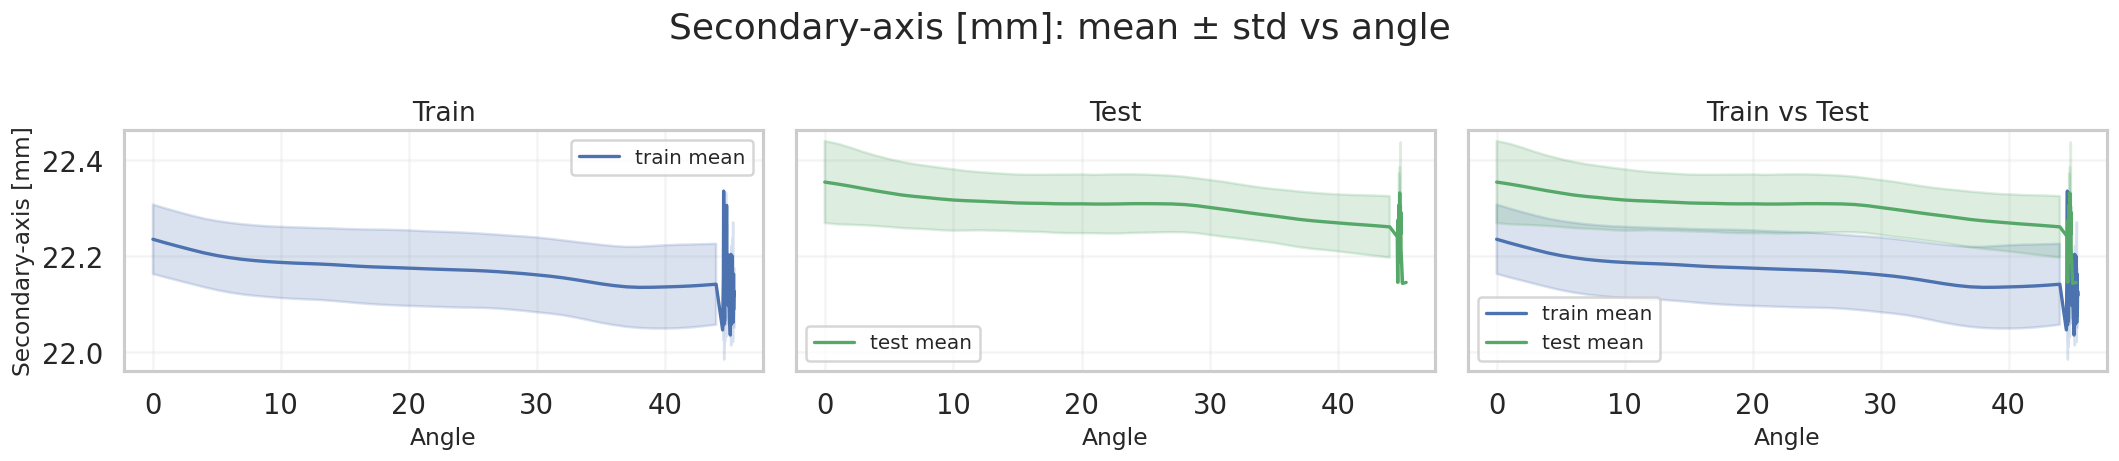

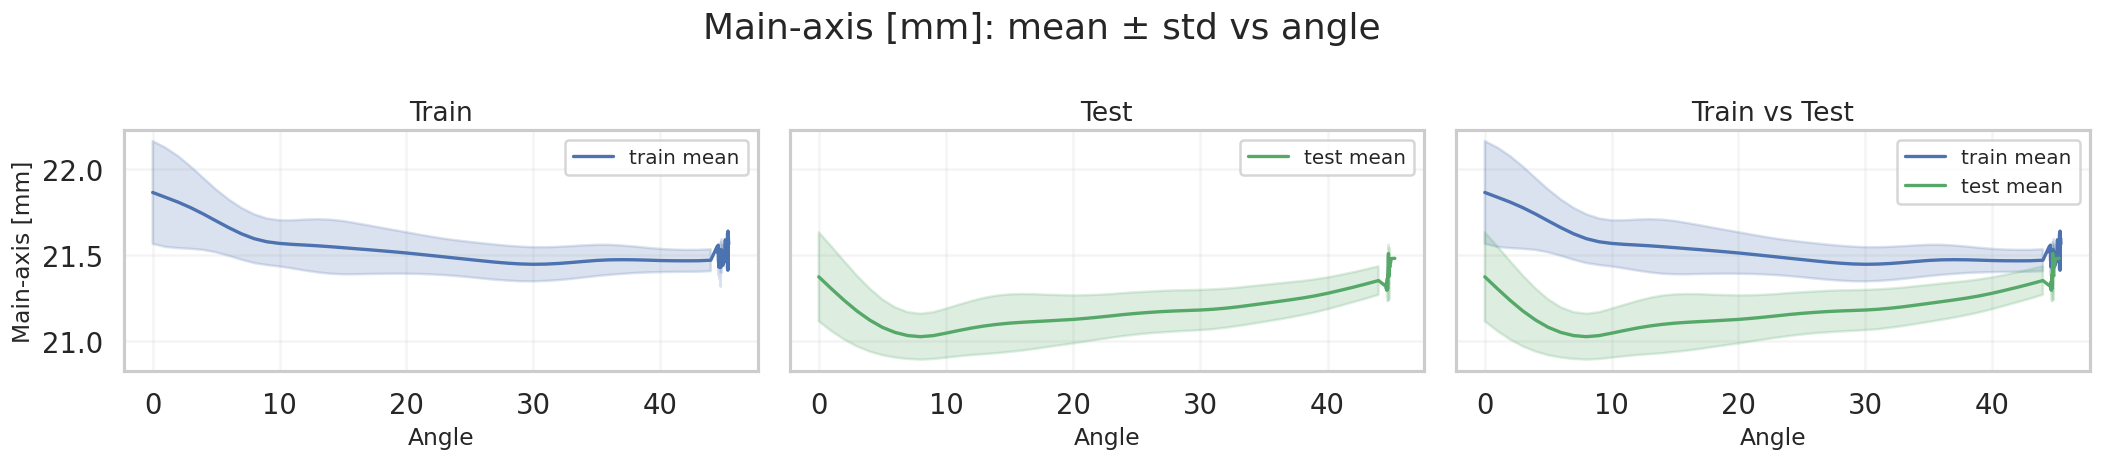

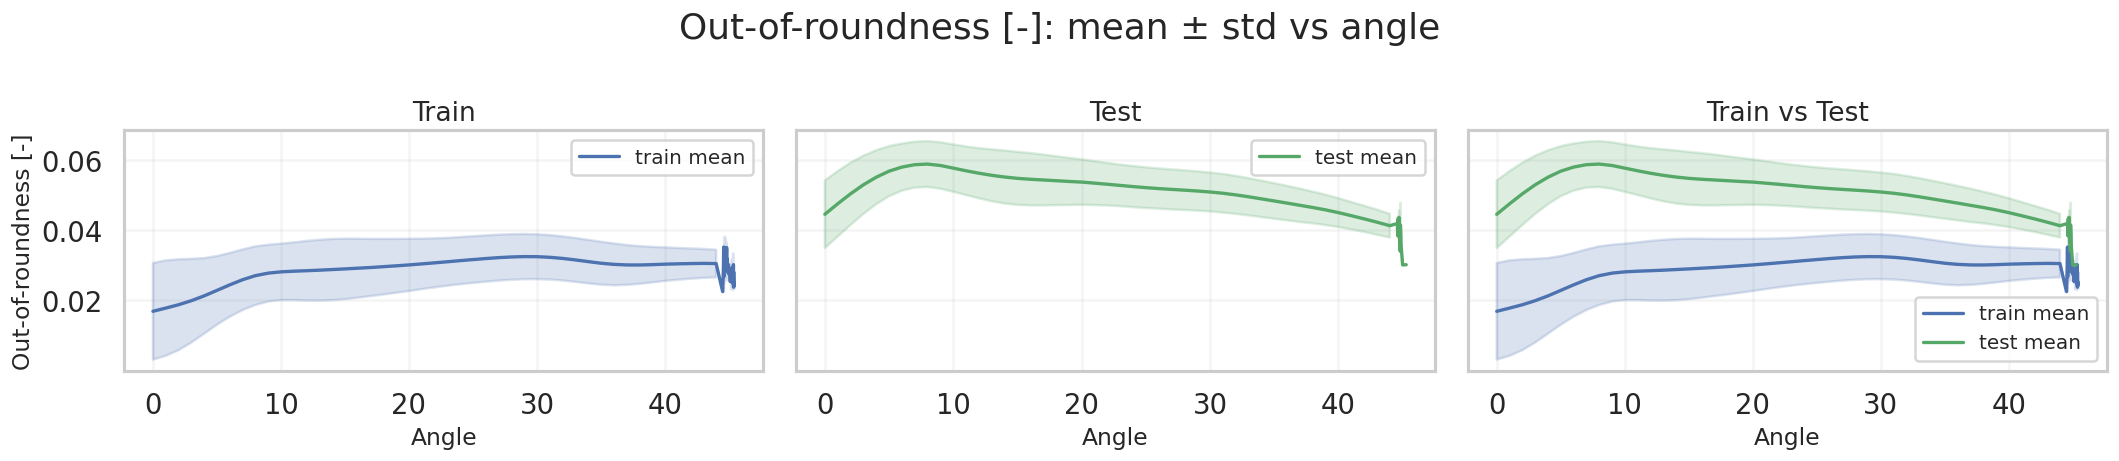

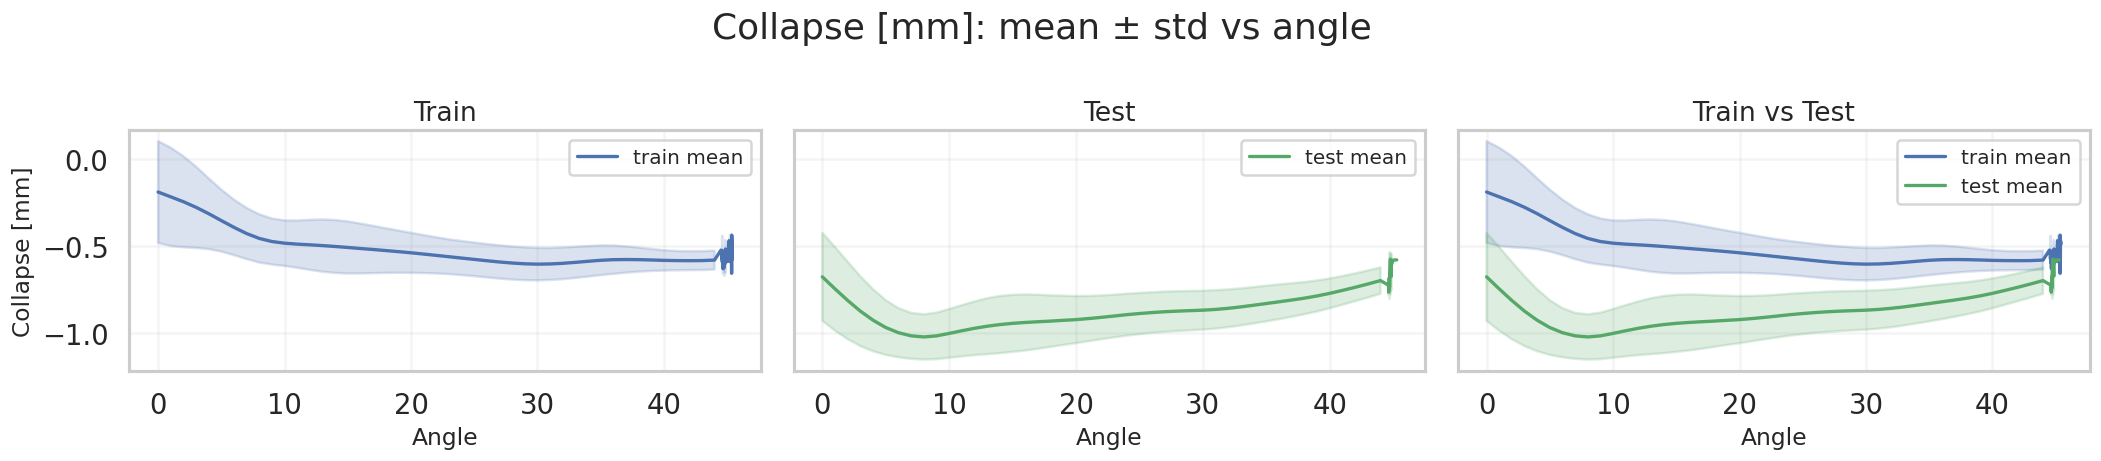

In [303]:
# Mean/std by angle for train and test splits
plot_mean_std_by_angle_train_test(split_config_path, df, feature_cols)